# Визуальное тестирование модели

Прогоняем обученную модель (`models/best_model.pt`) на случайных изображениях из test-сплита и смотрим предсказания + уверенность.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import random

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from src.config import CLASS_NAMES, RAW_DIR
from src.dataset import load_splits
from src.predict import get_model, predict

model = get_model()
splits = load_splits()
print(f'test size: {len(splits["test"])}')

test size: 2501


## 1. Grid случайных предсказаний

Зелёная рамка — верно, красная — ошибка.

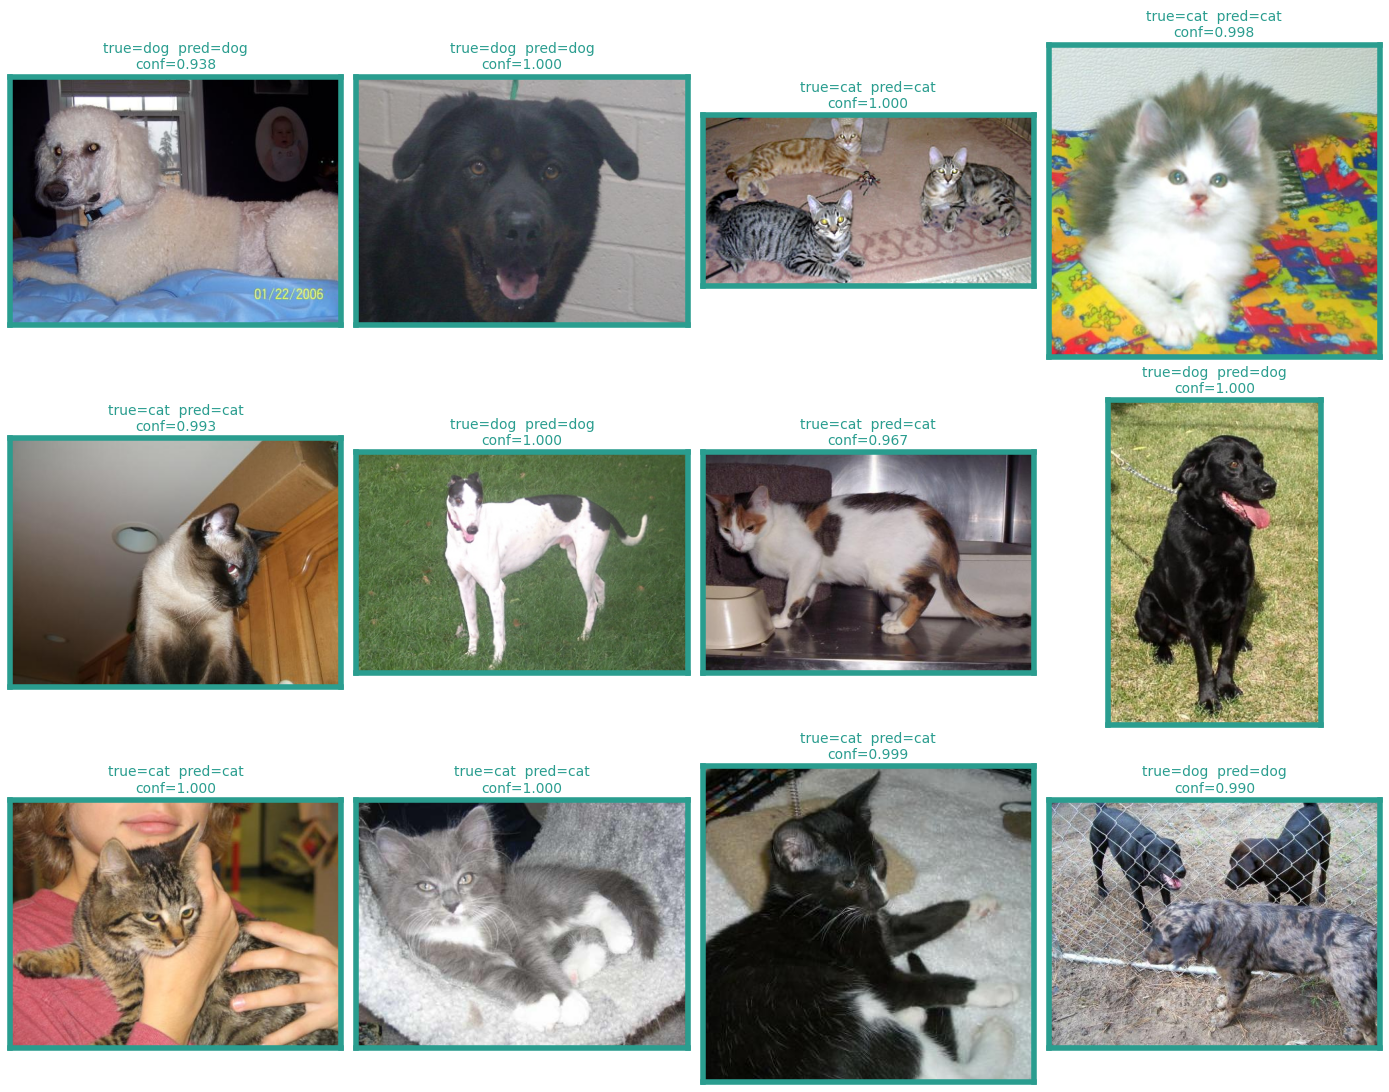

In [2]:
rng = random.Random(7)
sample = rng.sample(splits['test'], 12)

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, rel in zip(axes.flat, sample):
    img = Image.open(RAW_DIR / rel).convert('RGB')
    true_cls = Path(rel).parent.name.lower()
    pred = predict(img, model=model)
    correct = pred.label == true_cls
    color = '#2a9d8f' if correct else '#e63946'
    ax.imshow(img); ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(4)
    ax.set_title(f'true={true_cls}  pred={pred.label}\nconf={pred.confidence:.3f}', fontsize=10, color=color)
plt.tight_layout(); plt.show()

## 2. Загрузи свою картинку

Положи файл в `notebooks/` и подставь имя ниже.

In [3]:
# path = Path('my_pet.jpg')  # раскомментируй и подставь своё имя
path = None

if path and path.exists():
    img = Image.open(path).convert('RGB')
    pred = predict(img, model=model)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [2, 1]})
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f'{pred.label}  (confidence={pred.confidence:.3f})', fontsize=14)
    ax2.barh(list(pred.probs.keys()), list(pred.probs.values()), color=['#f4a261', '#2a9d8f'])
    ax2.set_xlim(0, 1); ax2.set_title('P(class)')
    plt.tight_layout(); plt.show()
else:
    print('укажи путь к картинке в переменной path выше')

укажи путь к картинке в переменной path выше


## 3. Распределение уверенности по всему тесту

In [4]:
import torch
from torch.utils.data import DataLoader
from src.dataset import CatDogDataset, eval_transform
from src.config import DEVICE, BATCH_SIZE

ds = CatDogDataset(splits['test'], transform=eval_transform())
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

all_probs, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in loader:
        probs = torch.softmax(model(x.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.append(probs); all_labels.append(y.numpy())
all_probs = np.concatenate(all_probs); all_labels = np.concatenate(all_labels)
preds = all_probs.argmax(axis=1)
confidences = all_probs.max(axis=1)
correct_mask = preds == all_labels
print(f'accuracy: {correct_mask.mean():.4f}')
print(f'средняя уверенность (верные): {confidences[correct_mask].mean():.4f}')
print(f'средняя уверенность (ошибки): {confidences[~correct_mask].mean():.4f}')

accuracy: 0.9832
средняя уверенность (верные): 0.9755
средняя уверенность (ошибки): 0.6982


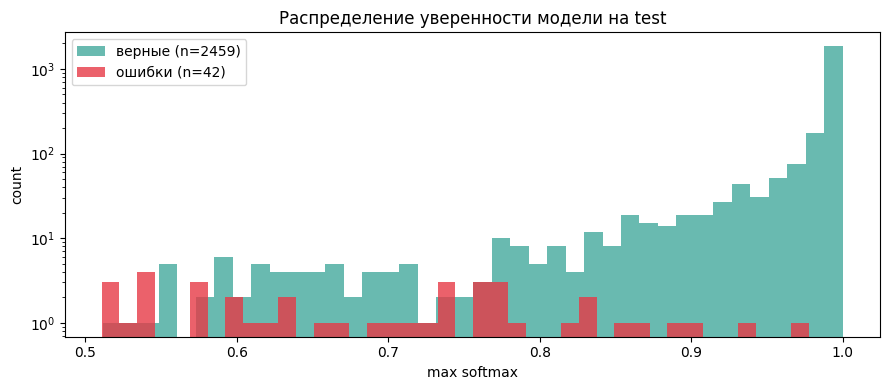

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(confidences[correct_mask], bins=40, alpha=0.7, label=f'верные (n={correct_mask.sum()})', color='#2a9d8f')
ax.hist(confidences[~correct_mask], bins=40, alpha=0.8, label=f'ошибки (n={(~correct_mask).sum()})', color='#e63946')
ax.set_xlabel('max softmax'); ax.set_ylabel('count'); ax.set_yscale('log')
ax.set_title('Распределение уверенности модели на test'); ax.legend()
plt.tight_layout(); plt.show()

Хорошо откалиброванная модель: верные предсказания группируются у 1.0, ошибки имеют заметно более низкую уверенность и распределены шире → `confidence` можно использовать как сигнал для human-in-the-loop.